# Modelado

El EDA dejó la vara en pesos y `02_feature_engineering.ipynb` dejó el pipeline verificado. Acá se elige
el modelo, y la pregunta se responde en pesos:

**¿Algún modelo convierte la señal en plata, y cuánta más que la regla que ya existe?**

Tres reglas de la casa, para que los números signifiquen algo:

- **La ganancia se reporta como diferencia contra aprobar todo.** Aprobar todo ya rinde plata, así que
  la ganancia absoluta de un modelo mide sobre todo el volumen del período. Lo que se decide acá es
  cuánto agrega **rechazar**.
- **Fold por fold, nunca solo el promedio.** La tasa de fraude se mueve entre períodos de una misma
  semana, y un promedio esconde el fold donde una política pierde plata.
- **El período desde el 13 de abril no se toca.** No aparece en esta notebook. Se usa una única vez, al
  final de `04_tuning.ipynb`, cuando ya no queda nada por elegir.

La escalera es **regresión logística → Random Forest → XGBoost**, cada uno con y sin `score`. Después,
las técnicas para target desbalanceado y el canal no supervisado, que se miden en vez de suponerse.

## 1. Contra qué se compara

Tres referencias, todas medidas sobre la validación de cada fold:

- **Aprobar todo**: el piso. Es la política actual si no hubiera modelo.
- **El máximo alcanzable**: aprobar todas las legítimas y ningún fraude. Ningún modelo lo supera, y la
  distancia entre el piso y el techo es lo único que está realmente en disputa.
- **La mejor regla de un corte sobre `score`**: la vara. El corte se elige con el entrenamiento de cada
  fold y se mide en su validación, que es la forma honesta de medirla.

**Hipótesis.** Si `score` fuera un buen detector de fraude por sí solo, un corte sobre él tendría que
quedarse con una porción grande de lo que está en disputa y hacerlo de forma pareja entre períodos. El
EDA ya sugirió lo contrario, así que se espera lo opuesto: una fracción chica y despareja.

In [1]:
import time

import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as PipelineConMuestreo
from imblearn.under_sampling import RandomUnderSampler
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from fraud_detection.constants import DATE, N_SPLITS, RANDOM_STATE, TARGET
from fraud_detection.dataset import load_transactions, normalize_text, split_development
from fraud_detection.evaluation import (
    expected_gain,
    max_gain,
    optimal_probability_threshold,
    sweep_gain,
)
from fraud_detection.features import build_preprocessor
from fraud_detection.modeling import temporal_folds
from fraud_detection.plots import plot_gain_curve

development, _ = split_development(normalize_text(load_transactions()))
X, y = development.drop(columns=[TARGET]), development[TARGET]
folds = list(temporal_folds(development[DATE], n_splits=N_SPLITS))
UMBRAL = optimal_probability_threshold()
GRILLA = np.round(np.arange(0.02, 0.92, 0.01), 2)
NOMBRES = [f"fold {numero}" for numero in range(len(folds))]


def todo_aprobado(frame: pd.DataFrame) -> pd.Series:
    """Máscara de la política actual: aprobar todas las transacciones."""
    return pd.Series(True, index=frame.index)


referencias = []
for train_pos, valid_pos in folds:
    train, valid = development.iloc[train_pos], development.iloc[valid_pos]
    corte = sweep_gain(train, train.score, range(0, 101)).idxmax()
    piso = expected_gain(valid, todo_aprobado(valid))
    referencias.append(
        {
            "filas_valid": len(valid),
            "aprobar_todo": piso,
            "maximo": max_gain(valid),
            "en_disputa": max_gain(valid) - piso,
            "corte_score": corte,
            "regla_score": expected_gain(valid, valid.score.lt(corte).fillna(False)) - piso,
        }
    )

referencias = pd.DataFrame(referencias, index=NOMBRES)
referencias.loc["total"] = referencias.sum()
referencias.loc["total", "corte_score"] = np.nan
display(referencias.round(0))
print(f"Umbral teórico de aprobación: p < {UMBRAL} | fraude en desarrollo: {y.mean():.2%}")

,filas_valid,aprobar_todo,maximo,en_disputa,corte_score,regla_score
fold 0,25199.0,189217.0,276718.0,87501.0,93.0,-1127.0
fold 1,20069.0,122878.0,200445.0,77567.0,98.0,1074.0
fold 2,17434.0,85648.0,155440.0,69792.0,95.0,7212.0
fold 3,24443.0,128269.0,221090.0,92822.0,93.0,16840.0
total,87145.0,526012.0,853693.0,327681.0,NaN,23999.0


Umbral teórico de aprobación: p < 0.2 | fraude en desarrollo: 5.18%


**Lectura: la vara es chica y no es estable.**

Sobre los cuatro bloques de validación hay **327.681 en disputa** entre aprobar todo y la predicción
perfecta. La regla de un corte sobre `score` se queda con **+23.999**, el 7,3% de esa brecha. Y lo hace
de forma despareja: en el fold 0 **pierde 1.127** y recién en el fold 3 llega a +16.840. El corte
elegido tampoco es estable, se mueve entre 93 y 98.

Ese +23.999 es el número a superar. El techo de 327.681 dice cuánto margen queda por encima.

## 2. Tres modelos, con y sin `score`

Los tres reciben **las mismas features**: `build_preprocessor(scale=True)` para la logística, que es
sensible a la escala, y `scale=False` para los árboles, a los que no les cambia nada. Así la comparación
mide el modelo y no el preprocesamiento.

Cada uno se entrena **dos veces**: una con la columna `score` y otra sin ella, que es lo que hace
`build_preprocessor(use_score=False)`. Es la columna **variante** de las tablas. `score` parece ser el
puntaje de riesgo de un sistema anterior y **todavía no está confirmado que esté disponible en el momento
de decidir el pago**; si se calculara después de conocer el resultado de la transacción, usarlo sería una
fuga. Medir las dos variantes deja el trabajo a salvo de esa respuesta y, de paso, dice cuánto del
resultado se apoya en un dato ajeno.

Dos decisiones que conviene dejar explícitas antes de mirar la tabla:

- **Ninguno reponderá las clases en esta sección.** *Reponderar* es hacer que cada fraude pese más que
  una transacción legítima cuando el modelo entrena: la función de pérdida suma el error de todas las
  filas, y si el 95% son legítimas el modelo puede bajar esa suma atendiendo sobre todo a ellas. Se hace
  con `class_weight="balanced"` en sklearn o `scale_pos_weight` en XGBoost; remuestrear (SMOTE,
  undersampling) persigue lo mismo cambiando la composición de los datos en vez de los pesos. Con 5% de
  fraude la tentación es aplicarlo por reflejo; acá se deja igual para los tres, de modo que la
  comparación sea pareja, y el efecto de esas técnicas se mide aparte en la sección 4.
- **El umbral es el teórico, 0,2, para todos.** Si se eligiera el mejor corte mirando la misma
  validación donde después se reporta, la ganancia saldría optimista por construcción —el EDA ya mostró
  ese efecto con `score`—. Si ese umbral es el correcto se pone a prueba en la sección 3.

**Hipótesis.** Los árboles deberían sacarle ventaja a la logística en AUC, porque el EDA mostró que `o`,
`n` y el horario interactúan y la logística solo captura interacciones si se las escribe a mano. La
pregunta que eso deja abierta, y que es la que importa, es si esa ventaja en ordenar transacciones se
paga en pesos cuando la decisión se toma con un único corte.

In [2]:
MODELOS = {
    "logistica": (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), True),
    "random forest": (
        RandomForestClassifier(
            n_estimators=400, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE
        ),
        False,
    ),
    "xgboost": (
        XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            eval_metric="aucpr",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        False,
    ),
}

probabilidades = {}


def evaluar(nombre: str, estimador, scale: bool, use_score: bool) -> list[dict]:
    """Entrenar en cada fold y medir su validación con el umbral teórico."""
    filas = []
    for numero, (train_pos, valid_pos) in enumerate(folds):
        inicio = time.time()
        pipeline = Pipeline(
            [
                ("preprocesamiento", build_preprocessor(scale=scale, use_score=use_score)),
                ("modelo", clone(estimador)),
            ]
        )
        pipeline.fit(X.iloc[train_pos], y.iloc[train_pos])
        valid = development.iloc[valid_pos]
        probabilidad = pd.Series(pipeline.predict_proba(X.iloc[valid_pos])[:, 1], index=valid.index)
        probabilidades[(nombre, use_score, numero)] = probabilidad
        filas.append(
            {
                "modelo": nombre,
                "variante": "con score" if use_score else "sin score",
                "fold": NOMBRES[numero],
                "auc": roc_auc_score(valid[TARGET], probabilidad),
                "ap": average_precision_score(valid[TARGET], probabilidad),
                "ganancia": expected_gain(valid, probabilidad.lt(UMBRAL))
                - expected_gain(valid, todo_aprobado(valid)),
                "segundos": time.time() - inicio,
            }
        )
    return filas


resultados = pd.DataFrame(
    [
        fila
        for nombre, (estimador, scale) in MODELOS.items()
        for use_score in (True, False)
        for fila in evaluar(nombre, estimador, scale, use_score)
    ]
)

ganancia = resultados.pivot_table(index=["modelo", "variante"], columns="fold", values="ganancia")
ganancia["total"] = ganancia.sum(axis=1)
display(ganancia.round(0))
display(
    resultados.groupby(["modelo", "variante"])
    .agg(auc=("auc", "mean"), ap=("ap", "mean"), segundos=("segundos", "sum"))
    .round(4)
)
print(
    f"Vara a superar (regla de un corte sobre score): {referencias.loc['total', 'regla_score']:,.0f}"
)

fold                      fold 0   fold 1   fold 2   fold 3     total
modelo        variante                                               
logistica     con score  30231.0  25780.0  29713.0  41692.0  127416.0
              sin score  25855.0  23542.0  25587.0  35536.0  110520.0
random forest con score  26216.0  31738.0  28811.0  39004.0  125769.0
              sin score  22413.0  25355.0  26332.0  31617.0  105717.0
xgboost       con score  27766.0  30049.0  32132.0  38754.0  128701.0
              sin score  21912.0  24974.0  27794.0  34414.0  109094.0

auc      ap  segundos
modelo        variante                           
logistica     con score  0.8434  0.3690    0.7581
              sin score  0.8412  0.3234    0.6975
random forest con score  0.8734  0.4597   10.6203
              sin score  0.8425  0.3844   10.6411
xgboost       con score  0.8834  0.4614    4.4912
              sin score  0.8461  0.3851    4.4637

Vara a superar (regla de un corte sobre score): 23,999


**Lectura: el salto está en usar un modelo, no en cuál.**

Los tres superan la vara por un factor de cinco: **+127.416** la logística, **+125.769** Random Forest y
**+128.701** XGBoost, contra los +23.999 de la regla de un corte. XGBoost captura el **39,3%** de los
327.681 en disputa. Y ninguno pierde plata en ningún fold, ni siquiera en el fold 0 donde la regla sobre
`score` perdía.

Lo interesante es la distancia entre modelos: **1%**. La logística queda a 1.285 de XGBoost teniendo
0,04 menos de AUC (0,843 contra 0,883) y 0,09 menos de average precision. La ventaja de los árboles en
ordenar transacciones es real, pero casi no se paga en pesos, porque la decisión no usa el orden
completo: usa un solo corte, y ahí lo que importa es acertar en las transacciones grandes.

**Qué aporta cada familia**, ya con los números de la tabla a la vista:

| Modelo | Qué aporta acá | Qué cuesta |
|---|---|---|
| **Regresión logística** | El piso de referencia y un coeficiente por feature, con signo y magnitud interpretables sin herramientas extra. Es la más barata de entrenar de las tres | Solo captura interacciones si se las escribe a mano, y necesita escalado e imputación cuidadosos |
| **Random Forest** | Interacciones y no linealidades sin pedirlas, promediando árboles decorrelacionados: gana 0,03 de AUC y 0,09 de AP sobre la logística | La más cara de las tres en tiempo, y sus probabilidades son promedios de votos, no estimaciones calibradas |
| **XGBoost** | Lo mismo que RF pero ajustando los errores del árbol anterior en vez de promediar: el mejor AUC, el mejor AP y la mejor ganancia, en menos de la mitad del tiempo de RF | Muchos hiperparámetros, así que es el que más depende de una búsqueda ordenada, y agrega una dependencia compilada al proyecto |

**Sacar `score` cuesta entre el 13% y el 16%**, según el modelo: la logística baja a +110.520 y XGBoost
a +109.094. Vale como respuesta a la pregunta abierta del EDA — si el dueño del dato confirma que
`score` no está disponible al decidir el pago, el modelo sigue rindiendo cuatro veces la vara actual.

Se sigue con XGBoost, que es el mejor en las tres métricas, sabiendo que la logística es una alternativa
a un 1% de distancia si se prefiere interpretabilidad.

## 3. ¿Aguanta el umbral teórico?

El 0,2 sale del despeje de la regla de negocio, no de los datos: conviene aprobar cuando
`0,25 × m × (1 − p) > m × p`. Pero ese despeje supone que la probabilidad predicha **es** la probabilidad
real. Si el modelo predice 0,15 donde la realidad es 0,25, el umbral correcto sobre sus salidas no es
0,2.

**Hipótesis.** Si el modelo estuviera bien calibrado, el corte que maximiza la ganancia en cada fold
tendría que caer cerca de 0,2. Si se desvía siempre para el mismo lado, la desviación no es ruido: es
calibración, y tiene que verse también en la curva de calibración. Y si es calibración, recalibrar
tendría que devolver la ganancia perdida.

Dos mediciones, entonces: barrer todos los cortes y ver dónde cae el máximo de cada fold, y comparar
probabilidad predicha contra fraude observado.

**Qué quiere decir "calibrar".** Un modelo está calibrado si, cuando dice 0,10, aproximadamente el 10%
de esas transacciones termina siendo fraude. Eso es distinto de ordenar bien: un modelo puede poner
todos los fraudes arriba —AUC alto— y aun así decir 0,05 donde la realidad es 0,15. Calibrar es agregarle
al final una función que traduzca sus probabilidades a la escala real, aprendida con datos de
entrenamiento. Hay dos formas clásicas, y se prueban las dos:

| Método | Qué hace | Cuándo conviene |
|---|---|---|
| **Isotónica** | Ajusta una escalera que solo puede subir, sin suponer ninguna forma: mira qué fraude real corresponde a cada nivel de probabilidad predicha y arma la correspondencia | Flexible, corrige cualquier deformación, pero necesita muchos datos en cada tramo y se vuelve inestable donde hay pocos casos —la cola, que es justo donde se decide— |
| **Sigmoide** (Platt) | Ajusta una curva en S con solo dos parámetros | Rígida: no puede corregir formas raras, pero con pocos datos es más estable |

Las dos se ajustan con una validación cruzada interna **sobre el entrenamiento** de cada fold, nunca
sobre la validación donde después se las mide.

,mejor_umbral,ganancia_mejor,ganancia_umbral_02,probabilidad_media,fraude_real,costo_de_usar_02
fold 0,0.15,31839.9975,27765.885,0.0416,0.0456,-4074.1125
fold 1,0.12,31727.5825,30049.290,0.0476,0.0569,-1678.2925
fold 2,0.14,34651.9500,32131.810,0.0492,0.0578,-2520.1400
fold 3,0.12,39911.7475,38754.155,0.0463,0.0541,-1157.5925


Usar 0,2 en vez del mejor corte de cada fold cuesta 9,430 sobre los cuatro


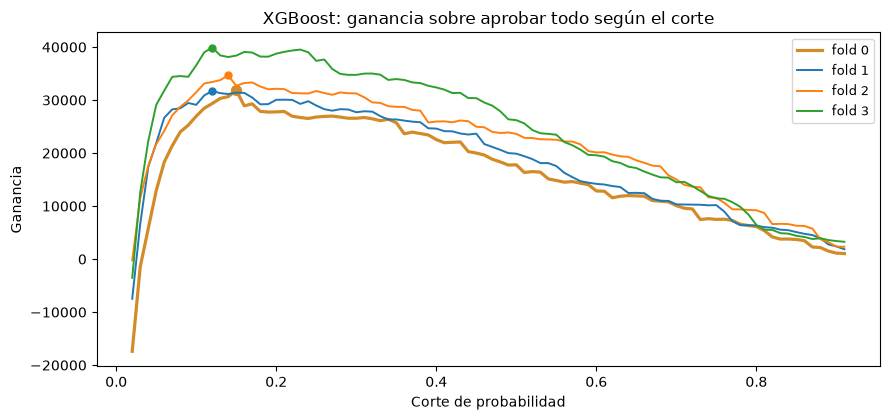

In [3]:
curvas, umbrales = {}, []
for numero, (_, valid_pos) in enumerate(folds):
    valid = development.iloc[valid_pos]
    probabilidad = probabilidades[("xgboost", True, numero)]
    piso = expected_gain(valid, todo_aprobado(valid))
    curva = sweep_gain(valid, probabilidad, GRILLA) - piso
    curvas[NOMBRES[numero]] = curva
    umbrales.append(
        {
            "mejor_umbral": curva.idxmax(),
            "ganancia_mejor": curva.max(),
            "ganancia_umbral_02": expected_gain(valid, probabilidad.lt(UMBRAL)) - piso,
            "probabilidad_media": probabilidad.mean(),
            "fraude_real": valid[TARGET].mean(),
        }
    )

umbrales = pd.DataFrame(umbrales, index=NOMBRES)
umbrales["costo_de_usar_02"] = umbrales.ganancia_umbral_02 - umbrales.ganancia_mejor
display(umbrales.round(4))
print(
    f"Usar 0,2 en vez del mejor corte de cada fold cuesta "
    f"{-umbrales.costo_de_usar_02.sum():,.0f} sobre los cuatro"
)
plot_gain_curve(
    curvas,
    title="XGBoost: ganancia sobre aprobar todo según el corte",
    xlabel="Corte de probabilidad",
);

**Lectura: el óptimo está por debajo de 0,2 y se mueve.**

El mejor corte de cada fold cae entre **0,12 y 0,15**, nunca en 0,2, y usar el teórico cuesta entre
**1.158 y 4.074** por fold: **9.430 sobre los cuatro**, un 7,3% de la ganancia.

El gráfico matiza ese costo: las cuatro curvas forman una meseta ancha, más o menos entre 0,1 y 0,3, así
que dentro de ese rango errar el corte sale barato. Lo que se paga caro es quedarse por debajo de 0,05,
donde se rechaza tanto que la ganancia cae por debajo de la de aprobar todo.

Las dos últimas columnas sugieren de dónde viene el corrimiento. En los cuatro folds la probabilidad
media predicha (4,2% a 4,9%) queda por debajo de la tasa real de fraude (4,6% a 5,8%): el modelo
subestima, así que su 0,2 corresponde a una probabilidad real más alta y el corte que equilibra los
costos queda más abajo. Si eso es así, calibrar tendría que acercar el óptimo a 0,2 y recuperar esa
diferencia.

In [4]:
_, ultimo_valid = folds[-1]
valid = development.iloc[ultimo_valid]
observada, predicha = calibration_curve(
    valid[TARGET], probabilidades[("xgboost", True, len(folds) - 1)], n_bins=10, strategy="quantile"
)
display(pd.DataFrame({"probabilidad predicha": predicha, "fraude observado": observada}).round(4))

calibracion = []
for numero, (train_pos, valid_pos) in enumerate(folds):
    valid = development.iloc[valid_pos]
    piso = expected_gain(valid, todo_aprobado(valid))
    fila = {
        "crudo": expected_gain(valid, probabilidades[("xgboost", True, numero)].lt(UMBRAL)) - piso
    }
    for nombre, metodo in {"isotonica": "isotonic", "sigmoide": "sigmoid"}.items():
        envuelto = CalibratedClassifierCV(
            Pipeline(
                [
                    ("preprocesamiento", build_preprocessor()),
                    ("modelo", clone(MODELOS["xgboost"][0])),
                ]
            ),
            method=metodo,
            cv=3,
        )
        envuelto.fit(X.iloc[train_pos], y.iloc[train_pos])
        probabilidad = pd.Series(envuelto.predict_proba(X.iloc[valid_pos])[:, 1], index=valid.index)
        fila[nombre] = expected_gain(valid, probabilidad.lt(UMBRAL)) - piso
        fila[f"probabilidad_media_{nombre}"] = probabilidad.mean()
    calibracion.append(fila)

calibracion = pd.DataFrame(calibracion, index=NOMBRES)
calibracion.loc["total"] = calibracion.sum()
display(calibracion.round(4))

,probabilidad predicha,fraude observado
0,0.0011,0.0004
1,0.0022,0.0029
2,0.0037,0.0045
3,0.0057,0.0090
4,0.0085,0.0123
5,0.0126,0.0225
6,0.0195,0.0250
7,0.0331,0.0389
8,0.0739,0.0974
9,0.3023,0.3280


,crudo,isotonica,probabilidad_media_isotonica,sigmoide,probabilidad_media_sigmoide
fold 0,27765.885,28064.5750,0.0457,24843.6075,0.0472
fold 1,30049.290,30538.6375,0.0493,28286.6325,0.0502
fold 2,32131.810,31431.8975,0.0501,29124.7725,0.0507
fold 3,38754.155,37375.3625,0.0469,36789.8800,0.0483
total,128701.140,127410.4725,0.1920,119044.8925,0.1964


**Lectura: la subestimación es sistemática, pero recalibrar no la paga.**

En nueve de los diez deciles del último fold el fraude observado supera a la probabilidad predicha
—0,0123 contra 0,0085, 0,0974 contra 0,0739—, así que la subestimación no es el efecto de un decil
suelto.

Aun así, ninguna de las dos calibraciones mejora la ganancia: la isotónica queda en **+127.410** y la
sigmoide en **+119.045**, contra **+128.701** del modelo crudo. La isotónica sí corrige el promedio
—0,0457 contra los 0,0416 del fold 0— y aun así no gana plata. Lo que dicen esos dos resultados juntos
es que el error de calibración que importa no está en el promedio sino en la zona del corte, que es la
única que decide. La sigmoide directamente empeora.

**Decisión: modelo crudo con el umbral 0,2.** Los 9.430 que deja sobre la mesa son el precio de no
elegir el umbral mirando los mismos datos donde después se lo reporta.

## 4. Target desbalanceado: cuatro técnicas, medidas

El 5,18% de fraude invita a las recetas habituales. Vale la pena separar qué hace cada una, porque no
atacan el mismo problema:

| Técnica | Qué hace | Para qué se la suele usar |
|---|---|---|
| `scale_pos_weight` / `class_weight` | Reponderar: multiplica el peso de cada fraude en la función de pérdida, de modo que equivocarse con uno duela como equivocarse con 18,3 legítimas | Que el modelo no ignore la clase chica cuando la pérdida está dominada por la grande |
| **Undersampling** | Tira transacciones legítimas hasta llegar al ratio pedido | Entrenar más rápido y forzar el balance, a costa de descartar datos reales |
| **SMOTE** | Inventa fraudes sintéticos interpolando entre vecinos de la clase chica | Balancear sin tirar datos, cuando los positivos son muy pocos |
| **Recalibrar después** | Vuelve a mapear las probabilidades del modelo reponderado contra la prevalencia real | Deshacer el corrimiento que introducen las anteriores |

**La cuenta que permite ponerlas a prueba.** Reponderar los fraudes por un `factor` equivale a entrenar
sobre una población donde el fraude es `factor` veces más frecuente de lo que es en realidad. Las
probabilidades que devuelve ese modelo quedan en esa escala inventada, así que el umbral de negocio deja
de aplicarles tal cual. El corte equivalente sobre sus salidas es:

```
umbral_corregido = factor × umbral / (factor × umbral + 1 − umbral)
```

donde `umbral` es el corte que corresponde en la población real, acá 0,2, y `factor` es cuánto se
multiplicó el peso de los fraudes.

**Hipótesis, y es falsable.** Estas técnicas no agregan información, solo cambian la escala de las
probabilidades. Si eso es cierto se tienen que cumplir tres cosas a la vez: el AUC **no** mejora, la
probabilidad media se aleja de la tasa real de fraude, y aplicar el corte corregido con esa fórmula
devuelve la ganancia que el 0,2 perdió. Si en cambio alguna variante superara al modelo sin ajustar
incluso con el corte corregido, la hipótesis sería falsa: habría aprendido algo nuevo.

Las cinco variantes corren sobre XGBoost, los mismos folds y las mismas features, y se miden con AUC
(orden), average precision (orden en la clase chica), probabilidad media (escala) y ganancia.

In [5]:
def umbral_ajustado(factor: float, umbral: float = UMBRAL) -> float:
    """Corte equivalente cuando el entrenamiento reponderó los fraudes por `factor`."""
    return factor * umbral / (factor * umbral + (1 - umbral))


def estrategias(train_pos) -> dict:
    """Variantes de manejo del desbalanceo, con el factor de reponderación de cada una."""
    ratio = y.iloc[train_pos].eq(0).sum() / y.iloc[train_pos].eq(1).sum()
    crudo, pesado = clone(MODELOS["xgboost"][0]), clone(MODELOS["xgboost"][0])
    pesado.set_params(scale_pos_weight=ratio)
    return {
        "sin ajuste": (
            Pipeline([("preprocesamiento", build_preprocessor()), ("modelo", crudo)]),
            1.0,
        ),
        "scale_pos_weight": (
            Pipeline([("preprocesamiento", build_preprocessor()), ("modelo", pesado)]),
            ratio,
        ),
        "undersampling 1:4": (
            PipelineConMuestreo(
                [
                    ("preprocesamiento", build_preprocessor()),
                    (
                        "muestreo",
                        RandomUnderSampler(sampling_strategy=0.25, random_state=RANDOM_STATE),
                    ),
                    ("modelo", clone(crudo)),
                ]
            ),
            0.25 * ratio,
        ),
        "SMOTE 1:4": (
            PipelineConMuestreo(
                [
                    ("preprocesamiento", build_preprocessor()),
                    ("muestreo", SMOTE(sampling_strategy=0.25, random_state=RANDOM_STATE)),
                    ("modelo", clone(crudo)),
                ]
            ),
            0.25 * ratio,
        ),
        "scale_pos_weight + recalibrado": (
            CalibratedClassifierCV(
                Pipeline([("preprocesamiento", build_preprocessor()), ("modelo", clone(pesado))]),
                method="isotonic",
                cv=3,
            ),
            1.0,
        ),
    }


desbalanceo = []
for numero, (train_pos, valid_pos) in enumerate(folds):
    valid = development.iloc[valid_pos]
    piso = expected_gain(valid, todo_aprobado(valid))
    for nombre, (estimador, factor) in estrategias(train_pos).items():
        estimador.fit(X.iloc[train_pos], y.iloc[train_pos])
        probabilidad = pd.Series(
            estimador.predict_proba(X.iloc[valid_pos])[:, 1], index=valid.index
        )
        curva = sweep_gain(valid, probabilidad, GRILLA) - piso
        desbalanceo.append(
            {
                "estrategia": nombre,
                "auc": roc_auc_score(valid[TARGET], probabilidad),
                "ap": average_precision_score(valid[TARGET], probabilidad),
                "probabilidad_media": probabilidad.mean(),
                "g_umbral_02": expected_gain(valid, probabilidad.lt(UMBRAL)) - piso,
                "umbral_corregido": umbral_ajustado(factor),
                "g_umbral_corregido": expected_gain(valid, probabilidad.lt(umbral_ajustado(factor)))
                - piso,
                "mejor_umbral": curva.idxmax(),
            }
        )

desbalanceo = (
    pd.DataFrame(desbalanceo)
    .groupby("estrategia")
    .agg(
        auc=("auc", "mean"),
        ap=("ap", "mean"),
        probabilidad_media=("probabilidad_media", "mean"),
        g_umbral_02=("g_umbral_02", "sum"),
        umbral_corregido=("umbral_corregido", "mean"),
        g_umbral_corregido=("g_umbral_corregido", "sum"),
        umbral_optimo_min=("mejor_umbral", "min"),
        umbral_optimo_max=("mejor_umbral", "max"),
    )
)
display(desbalanceo.round(4))

,auc,ap,probabilidad_media,g_umbral_02,umbral_corregido,g_umbral_corregido,umbral_optimo_min,umbral_optimo_max
estrategia,,,,,,,,
SMOTE 1:4,0.8583,0.4383,0.1445,41138.1900,0.5492,121500.7650,0.33,0.60
scale_pos_weight,0.8787,0.4523,0.1910,3845.6825,0.8297,105839.5500,0.49,0.80
scale_pos_weight + recalibrado,0.8786,0.4541,0.0471,120146.1750,0.2000,120146.1750,0.12,0.20
sin ajuste,0.8834,0.4614,0.0462,128701.1400,0.2000,128701.1400,0.12,0.15
undersampling 1:4,0.8833,0.4526,0.1280,80567.6825,0.5492,123109.8925,0.33,0.60


**Lectura: la hipótesis se cumple en los tres puntos.**

**El orden casi no cambia.** El AUC se mueve entre 0,8583 y 0,8834, y el mejor de los cinco es
**no hacer nada** (0,8834 de AUC, 0,4614 de AP). SMOTE es el único que empeora de forma clara el AP
—0,4383 contra 0,4614—, lo cual es esperable: interpolar entre fraudes vecinos inventa casos que
suavizan el borde justo en la clase que importa.

**La escala, en cambio, se rompe.** La probabilidad media pasa de 0,0462 a **0,1910** con
`scale_pos_weight` y a 0,1280 con undersampling, contra un 5,3% real de fraude. Con el umbral 0,2 fijo
eso es catastrófico: la ganancia se desploma de **+128.701 a +3.846**. No porque el modelo sea peor, sino
porque su 0,2 ya no significa lo mismo.

**Y se puede deshacer con una cuenta, lo cual prueba de qué se trata.** Aplicando el corte corregido
—0,83 para `scale_pos_weight`, 0,55 para los dos remuestreos— la ganancia vuelve a 105.840, 123.110 y
121.501. Recupera casi todo, pero **ninguna supera los +128.701 de no hacer nada**. Es la confirmación de
que estas técnicas mueven la escala de las probabilidades y no aportan señal nueva. La misma cuenta
predice bien dónde queda el óptimo empírico: 0,55 calculado contra un óptimo medido entre 0,33 y 0,60.

**Decisión: no se corrige el desbalanceo.** Con 5,18% de fraude y los 5.929 casos positivos que contó el
EDA no hay una clase que el modelo esté ignorando. Y si se corrigiera —por ejemplo, si con un desbalanceo mucho más extremo el
modelo dejara de aprender la clase chica— quedaría claro qué hacer después: transformar el umbral con
la fórmula del `umbral_corregido` o recalibrar, nunca seguir usando el 0,2 sobre probabilidades
reponderadas.

Lo que sí exige un target desbalanceado es **elegir bien la métrica**. El accuracy no aparece en ninguna
tabla de esta notebook por eso: aprobar todo acierta el 94,8% de las veces y no detecta un solo fraude.
Por eso se reporta average precision, que mira la clase chica, y sobre todo ganancia en pesos, que es la
única que pondera cada error por lo que cuesta.

## 5. Isolation Forest: ¿sirve un canal no supervisado?

Es la pregunta obligada en fraude, porque "fraude" y "anomalía" suenan a lo mismo. Isolation Forest no
usa las etiquetas: aísla puntos raros. Tiene dos usos posibles y conviene medir los dos por separado —
como **detector por sí solo**, y como **una feature más** dentro del modelo supervisado.

**Hipótesis.** Si el fraude de este dataset fuera un fenómeno de rarezas, un detector de anomalías
tendría que acercarse a un modelo supervisado, y sumarlo como feature tendría que mejorar el AUC. El EDA
apunta a que no: el fraude ahí no aparecía en las colas de monto sino en patrones de `o`, `n`, `score` y
horario. Se espera entonces un detector claramente peor y una mejora marginal nula.

Se corre sobre las mismas features y los mismos folds, y se compara contra la logística, que es el
modelo más barato de la escalera.

In [6]:
anomalias = []
for numero, (train_pos, valid_pos) in enumerate(folds):
    escalado = build_preprocessor(scale=True).fit(X.iloc[train_pos], y.iloc[train_pos])
    matriz_train = escalado.transform(X.iloc[train_pos])
    matriz_valid = escalado.transform(X.iloc[valid_pos])

    detector = IsolationForest(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE).fit(
        matriz_train
    )
    rareza_train = -detector.score_samples(matriz_train)
    rareza_valid = -detector.score_samples(matriz_valid)

    sola = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    sola.fit(matriz_train, y.iloc[train_pos])
    con_rareza = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    con_rareza.fit(np.c_[matriz_train, rareza_train], y.iloc[train_pos])

    anomalias.append(
        {
            "iso_solo_auc": roc_auc_score(y.iloc[valid_pos], rareza_valid),
            "logistica_auc": roc_auc_score(
                y.iloc[valid_pos], sola.predict_proba(matriz_valid)[:, 1]
            ),
            "logistica_mas_iso_auc": roc_auc_score(
                y.iloc[valid_pos], con_rareza.predict_proba(np.c_[matriz_valid, rareza_valid])[:, 1]
            ),
        }
    )

anomalias = pd.DataFrame(anomalias, index=NOMBRES)
anomalias.loc["media"] = anomalias.mean()
display(anomalias.round(4))

,iso_solo_auc,logistica_auc,logistica_mas_iso_auc
fold 0,0.7450,0.8200,0.8199
fold 1,0.7517,0.8367,0.8365
fold 2,0.7578,0.8351,0.8349
fold 3,0.7501,0.8366,0.8363
media,0.7511,0.8321,0.8319


**Lectura: no se incluye, y el motivo no es el número sino lo que lo explica.**

Como detector solo llega a **0,7511** de AUC medio. No es ruido —ordena mejor que el azar— pero queda
muy por debajo de la logística supervisada (**0,8321**), y como feature adicional el AUC medio pasa de
0,8321 a **0,8319**: no aporta nada que las otras features no tengan ya.

El motivo está en el EDA: **fraude no es sinónimo de anomalía**. Ahí la mediana de monto en fraude era
25,70 contra 20,77 en legítimas, así que el fraude no vive en las colas; vive en patrones de `o`, `n`,
`score` y horario. Un detector de rarezas busca donde no está la señal. Y el EDA contó 5.929 fraudes
etiquetados en desarrollo: un método no supervisado descarta la información más cara del dataset.

**Dónde sí tiene argumento:** un modelo supervisado solo detecta fraude parecido al que ya vio. Un canal
no supervisado puede marcar patrones de ataque nuevos que nunca estuvieron etiquetados. Eso **no es
validable con este dataset** —por definición esos casos no tienen etiqueta—, así que es una propuesta
para el monitoreo en producción, como segundo canal que alimente revisión manual. Responde a la pregunta
sobre la puesta en producción, no a la elección del modelo.

## 6. El supuesto que sostiene todas las mediciones

Hasta acá cada fold entrena con todo lo anterior a una fecha y valida con la semana siguiente, sin dejar
nada en el medio. Eso supone algo fuerte: **que la etiqueta de fraude se conoce enseguida**.

En un sistema real casi nunca es así. Un fraude suele confirmarse cuando el titular desconoce el cargo, y
eso tarda. Si tardara siete días, al reentrenar en producción los últimos siete días **no tendrían
etiqueta confiable** y no se podrían usar. Entrenar en el laboratorio con datos que en producción no van
a estar es exactamente la clase de diferencia que hace que un número no se reproduzca.

El EDA no encontró patrón de demora, pero ese chequeo no puede ver una demora más larga que la ventana
observada: con 45 días de datos, una demora de 30 sería invisible. Así que en vez de suponer, se mide.
`temporal_folds` acepta `gap_days`, que descarta días **entre** el fin del entrenamiento y el inicio de
la validación, simulando esa demora.

**Hipótesis.** La ganancia debería caer a medida que el hueco crece, y la caída debería ser gradual, no
un derrumbe: el modelo aprende de patrones que duran más de una semana. Si en cambio se derrumbara con
un hueco de uno o dos días, el modelo estaría viviendo de información de muy corto plazo y sería frágil
en producción.

**Una advertencia para leer la tabla:** el hueco se come días de entrenamiento. Con `gap_days = 7` el
fold 0 entrena con un solo día. Parte de la caída es la demora y parte es tener menos datos, así que el
resultado es una **cota pesimista**, no la descomposición de las dos causas.

In [7]:
sensibilidad = []
for dias in (0, 1, 2, 3, 5, 7):
    folds_con_hueco = list(temporal_folds(development[DATE], n_splits=N_SPLITS, gap_days=dias))
    total, aucs = 0.0, []
    for train_pos, valid_pos in folds_con_hueco:
        pipeline = Pipeline(
            [("preprocesamiento", build_preprocessor()), ("modelo", clone(MODELOS["xgboost"][0]))]
        )
        pipeline.fit(X.iloc[train_pos], y.iloc[train_pos])
        valid = development.iloc[valid_pos]
        probabilidad = pd.Series(pipeline.predict_proba(X.iloc[valid_pos])[:, 1], index=valid.index)
        total += expected_gain(valid, probabilidad.lt(UMBRAL)) - expected_gain(
            valid, todo_aprobado(valid)
        )
        aucs.append(roc_auc_score(valid[TARGET], probabilidad))
    sensibilidad.append(
        {
            "gap_days": dias,
            "dias_train_fold_0": development[DATE]
            .iloc[folds_con_hueco[0][0]]
            .dt.normalize()
            .nunique(),
            "filas_validadas": sum(len(valid_pos) for _, valid_pos in folds_con_hueco),
            "ganancia": total,
            "auc": np.mean(aucs),
        }
    )

sensibilidad = pd.DataFrame(sensibilidad).set_index("gap_days")
sensibilidad["contra_gap_0"] = sensibilidad.ganancia - sensibilidad.ganancia.loc[0]
display(sensibilidad.round(4))

,dias_train_fold_0,filas_validadas,ganancia,auc,contra_gap_0
gap_days,,,,,
0,8,87145,128701.1400,0.8834,0.0000
1,7,87145,131200.5850,0.8839,2499.4450
2,6,87145,123628.1650,0.8827,-5072.9750
3,5,87145,126762.8250,0.8815,-1938.3150
5,3,87145,120951.8875,0.8769,-7749.2525
7,1,87145,117829.6450,0.8707,-10871.4950


**Lectura: la caída es gradual, y eso es una buena noticia.**

Con un hueco de **7 días** —la demora más larga que se probó— la ganancia pasa de +128.701 a
**+117.830**, un 8,4% menos, y el AUC de 0,8834 a 0,8707. Y eso con el fold 0 entrenando con **un solo
día** de historia. La hipótesis se sostiene: no hay derrumbe, así que el modelo no está viviendo de
información de las últimas horas.

La caída tampoco es ordenada, y eso también informa: entre 1 y 3 días de hueco la ganancia se mueve
entre **+2.499 y −5.073** respecto de no dejar ninguno, sin tendencia clara —con un hueco de 1 día da
más que sin hueco—. Esa dispersión es del mismo orden que la que ya vimos entre modelos: es ruido entre
folds. Recién con 5 y 7 días la caída se despega del ruido.

**Qué hacer con esto.** El supuesto de `gap = 0` se mantiene, porque no hay evidencia de demora y es el
que aprovecha todos los datos. Pero ahora está acotado: **si el dueño del dato informa una demora de
hasta una semana, el resultado baja alrededor de un 8%, no se cae.** Y el cambio es una línea:
`temporal_folds(..., gap_days=7)`.

## Lo que queda elegido

**XGBoost, sin reponderar, con el umbral 0,2 y `score` incluido.** Rinde **+128.701** sobre aprobar todo
en los cuatro bloques de validación, contra los **+23.999** de la mejor regla de un corte sobre `score`.

Lo que se descartó, con la medición al lado: Random Forest y la logística por un margen del 1%,
las cuatro variantes de manejo del desbalanceo porque ninguna agrega señal, las dos calibraciones porque
ninguna gana plata, e Isolation Forest porque el fraude de este dataset no está en las colas.

Todavía no se tocó el período reservado. Queda para `04_tuning.ipynb`, que hace dos cosas: buscar
hiperparámetros con Optuna sobre estos mismos folds, maximizando ganancia y no AUC, y recién ahí disparar
una única vez contra los 9 días guardados.

Queda anotado y sin resolver el desempeño **por país**, porque el modelo es global y según el EDA BR
aporta 4.880 de los 5.929 fraudes de desarrollo: falta verificar que AR no quede peor servida.